In [1]:
import time
import numpy as np
import os
import sys
# 将目录添加到 Python 路径
sys.path.append('/DATACENTER4/jiangbo.chai/SWJTU_OOPAO')
from OOPAO.Atmosphere import Atmosphere
from OOPAO.DeformableMirror import DeformableMirror
from OOPAO.Source import Source
from OOPAO.Telescope import Telescope
from OOPAO.ShackHartmann import ShackHartmann
from tutorials.scao_system.myAoSystem.Imager_new import Imager_new  # 导入新的科学相机模块
from tutorials.scao_system.myAoSystem.Imager import Imager # 导入之前的的科学相机模块
import matplotlib.pyplot as plt
import OOPAO.tools.displayTools as tools



     °          *      *      
 ▄██▄   ▄██▄  ▄███▄   ▄██▄ * ▄██▄ 
██* ██ ██  ██ ██  ██ ██  ██ ██  ██
██  ██ ██° ██ ██  ██ ██* ██ ██  ██
██  ██ ██  ██ ████▀  ██▄▄██ ██  ██
██* ██ ██  ██ ██     ██▀▀██ ██  ██
██  ██ ██  ██ ██ *   ██  ██ ██* ██
 ▀██▀   ▀██▀  ██   ° ██  ██  ▀██▀ 
      *         *             


**************************************************************************************************************************************************************
NUMPY WARNING: mkl blas not found! Multi-threading may not work as expected.
**************************************************************************************************************************************************************
1.26.2


In [2]:
ngs = Source(magnitude=0,optBand='H')

# 创建望远镜
tel = Telescope(resolution          = 120, # 分辨率
                diameter            = 8, # 直径
                samplingTime        = 1/1000, # 采样时间
                centralObstruction  = 0) # 中心遮挡比例
ngs * tel
atm = Atmosphere(
    telescope=tel,
    r0=0.15,  # 大气湍流的弗里德参数（Fried parameter），表示大气相干长度，单位为米
    L0=30,# 大气湍流的外尺度（Outer scale），单位为米
    altitude=[0,4000,10000],# 每个湍流层的海拔高度，单位为米
    fractionalR0=[0.7,0.25,0.05], # 每个湍流层的 Cn² 剖面，表示每个层对总湍流的贡献比例
    windSpeed=[5,10,20],# 每个湍流层的风速，单位为米/秒
    windDirection=[0,90,360])# 每个湍流层的风向，单位为度
atm.initializeAtmosphere(telescope=tel)


%%%%%%%%%%%%%%%%%%%%%%%%%%%%% SOURCE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
 Source Wavelength Zenith  Azimuth   Altitude Magnitude    Flux   
           [m]    [arcsec]  [deg]      [m]              [phot/m2/s]
-------------------------------------------------------------------
  NGS   1.654e-06    0        0        inf       -0.0   2989130434.8
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% TELESCOPE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
     Diameter             8                [m]        
    Resolution           120             [pixels]     
    Pixel Size           0.07              [m]        
     Surface             50.0              [m2]       
Central Obstruction        0          [% of diameter]  
Pixels in the pupil      11304            [pixels]     
      Source             None                         
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No light propagated through the telescope
-> Computing the 

In [3]:
src = Source(magnitude=5,optBand='I')
src*tel
print(tel.OPD.shape)


%%%%%%%%%%%%%%%%%%%%%%%%%%%%% SOURCE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
 Source Wavelength Zenith  Azimuth   Altitude Magnitude    Flux   
           [m]    [arcsec]  [deg]      [m]              [phot/m2/s]
-------------------------------------------------------------------
  NGS    7.9e-07     0        0        inf       5.0    73369565.2
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
(120, 120)


In [4]:
tel-atm
camH = Imager_new(diameter=tel.D,nyquist_sampling=4,field_stop_size=64,exposure_time=0.001,clock_rate=1000) # 创建科学相机
'''新的图像分辨率为nyquist_sampling*field_stop_size*2'''

# for _ in range(10):
#     camH.relay(tel.src)
#     camH.imagesc()


'新的图像分辨率为nyquist_sampling*field_stop_size*2'

fluxMap: (120, 120)
src.phase: (120, 120)


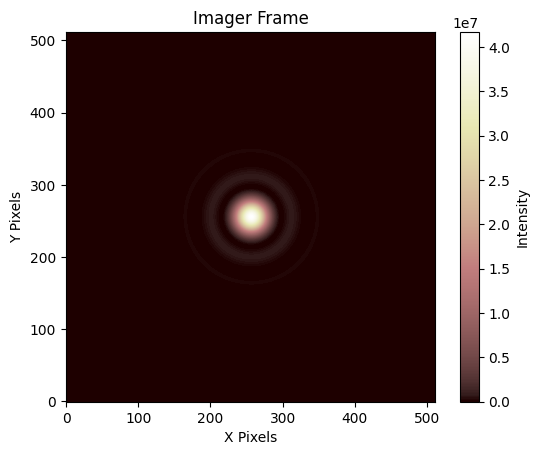

512


In [5]:
camH.relay(tel.src)
camH.referenceFrame = camH.frame
camH.imagesc()
print(camH.resolution)

In [6]:
print(camH.strehl)
tel+atm
camH.exposureTime=10


None


In [7]:
atm.update()
camH.relay(tel.src)
camH.imagesc()
print(camH.strehl)
'''新的SR是二维，直接取camH.strehl[0][0]就行'''

fluxMap: (120, 120)
src.phase: (120, 120)
没有图像可以显示。请先运行 'relay' 方法。
None


'新的SR是二维，直接取camH.strehl[0][0]就行'

In [8]:
# 创建变形镜
dm=DeformableMirror(telescope    = tel,
                    nSubap       = 20, # 沿望远镜直径的变形镜驱动器数，即总驱动数=nSubap*nSubap
                    mechCoupling = 0.1) # 驱动器之间的机械耦合系数,用于描述变形镜的各个驱动器之间的机械相互作用程度
# 创建SH-WFS 

wfs = ShackHartmann(nSubap              = 20, #  沿望远镜直径的子孔径数
                    telescope           = tel,
                    lightRatio          = 0.6, # 用于筛选有效子孔径
                    is_geometric        = False, # 是否启用几何模式（直接测量梯度）
                    threshold_cog       = 0.01) # 计算光斑质心时的阈值
gainCL                  = 0.6  # 传感增益

No coordinates loaded.. taking the cartesian geometry as a default
Generating a Deformable Mirror: 
Computing the 2D zonal modes...
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% DEFORMABLE MIRROR %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
Controlled Actuators        357        
         M4                False       
        Pitch               0.4               [m]        
 Mechanical Coupling        0.1               [%]        
-------------------------------------------------------------------------------
Mis-registration:
Rotation [deg]	Shift X [m]	Shift Y [m]	Radial Scaling [%]	Tangential Scaling [%]
      0       	     0     	     0     	        0         	          0           
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
Selecting valid subapertures based on flux considerations..


In [9]:
from OOPAO.calibration.ao_calibration import ao_calibration
from tutorials.scao_system.parameter_files.parameterFile_VLT_I_Band_SHWFS import initializeParameterFile

param = initializeParameterFile()

'''
加载或生成模态基,即模式到控制矩阵（M2C）用于将模式映射到变形镜（DM）的控制信号
计算或加载交互矩阵
'''
ao_calib =  ao_calibration(param            = param,\
                           ngs              = ngs,\
                           tel              = tel,\
                           atm              = atm,\
                           dm               = dm,\
                           wfs              = wfs,\
                           nameFolderIntMat = None,\
                           nameIntMat       = None,\
                           nameFolderBasis  = None,\
                           nameBasis        = None,\
                           nMeasurements    = 100)


Reading/Writting calibration data from data_calibration/
Writting output data in data_cl/
Loading the KL Modal Basis from: data_calibration/M2C_120_res
ERROR: No file found! Taking a zonal basis instead..
Loading Interaction matrix data_calibration/VLT_I_band_20x20/zonal_interaction_matrix_120_res_308_subap_diffractive...
ERROR: No file found! computing imat..
Interaction Matrix Computation:


  0%|          | 0/4 [00:00<?, ?it/s]

updating the flux of the SHWFS object


 25%|██▌       | 1/4 [00:01<00:04,  1.60s/it]

100/357
Time elapsed: 1.602950096130371 s


...

 75%|███████▌  | 3/4 [00:03<00:01,  1.28s/it]

300/357
Time elapsed: 1.1695518493652344 s


100%|██████████| 4/4 [00:04<00:00,  1.16s/it]

400/357
Time elapsed: 0.6519374847412109 s


No Modal Gains found. All gains set to 1


In [12]:
print(ngs.phase.shape,ngs.fluxMap.shape)

(120, 120) (120, 120)


None None None


/tmp/ipykernel_1407388/1561483181.py:61: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  SR_camH2[i] = camH2.strehl


Loop 1/200 - Elapsed time: 0.16 s
Turbulence: 772.89 nm -- Residual: 772.89 nm -- SR: 0.03

Loop 2/200 - Elapsed time: 0.25 s
Turbulence: 773.62 nm -- Residual: 773.62 nm -- SR: 0.04

Loop 3/200 - Elapsed time: 0.25 s
Turbulence: 774.36 nm -- Residual: 390.58 nm -- SR: 0.15

Loop 4/200 - Elapsed time: 0.25 s
Turbulence: 775.12 nm -- Residual: 251.26 nm -- SR: 0.45

Loop 5/200 - Elapsed time: 0.26 s
Turbulence: 775.92 nm -- Residual: 342.28 nm -- SR: 0.21

Loop 6/200 - Elapsed time: 0.26 s
Turbulence: 776.72 nm -- Residual: 288.20 nm -- SR: 0.34

Loop 7/200 - Elapsed time: 0.25 s
Turbulence: 777.46 nm -- Residual: 212.07 nm -- SR: 0.57

Loop 8/200 - Elapsed time: 0.26 s
Turbulence: 778.22 nm -- Residual: 221.36 nm -- SR: 0.52

Loop 9/200 - Elapsed time: 0.25 s
Turbulence: 779.01 nm -- Residual: 218.08 nm -- SR: 0.53

Loop 10/200 - Elapsed time: 0.25 s
Turbulence: 779.80 nm -- Residual: 183.50 nm -- SR: 0.67

Loop 11/200 - Elapsed time: 0.25 s
Turbulence: 780.61 nm -- Residual: 157.45 nm

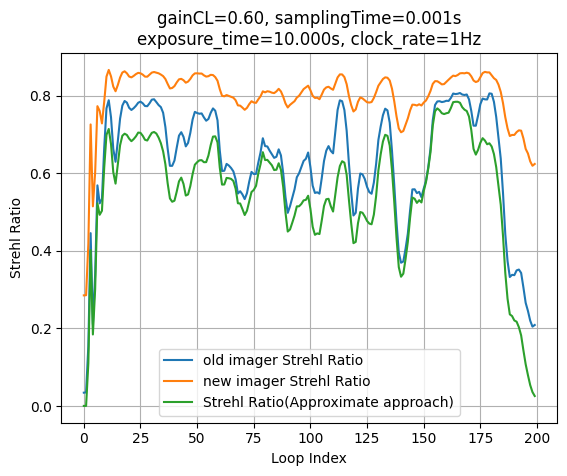

In [10]:
camH1 = Imager(diameter=tel.D,nyquist_sampling=4,field_stop_size=20,exposure_time=1,clock_rate=1)
camH2 = Imager_new(diameter=tel.D,nyquist_sampling=4,field_stop_size=20,exposure_time=1,clock_rate=1)
print(camH2.referenceFrame,camH2.frame,camH2.strehl)
# 闭环控制
calib_CL    = ao_calib.calib # 交互矩阵
M2C_CL      = ao_calib.M2C

tel+atm
ngs*tel*dm*wfs
# initialize DM commands
dm.coefs=0


param['nLoop'] = 200

wfs.cam.photonNoise = True  # 启用光子噪声
atm.initializeAtmosphere(telescope=tel)
# 分配内存以保存数据
SR_camH1 = np.zeros(param['nLoop'])  # 斯特列尔比
SR_camH2 = np.zeros(param['nLoop'])  # 斯特列尔比
SR_old = np.zeros(param['nLoop'])  # 近似方式斯特列尔比
total = np.zeros(param['nLoop'])  # 总波前误差
residual = np.zeros(param['nLoop'])  # 残余波前误差
wfsSignal = np.zeros(wfs.nSignal)  # 波前传感器信号

# 初始化变形镜控制信号
dm.coefs = 0
gainCL = 0.6  # 闭环控制增益
# 主循环
for i in range(param['nLoop']):
    start_time = time.time()

    # 更新大气湍流相位屏
    atm.update()

    tel-atm
    camH1.relay(tel.src)
    camH1.reference_frame = camH1.frame
    camH2.relay(tel.src)
    camH2.referenceFrame = camH2.frame
    tel+atm

    # 记录总的波前误差
    total[i] = np.std(tel.OPD[np.where(tel.pupil > 0)]) * 1e9

    # 光波传播：自然引导星 -> 望远镜 -> 变形镜 -> 波前传感器
    ngs * tel * dm * wfs
    # 更新变形镜控制信号
    dm.coefs = dm.coefs - gainCL * M2C_CL @ calib_CL.M @ wfsSignal

    # 更新波前传感器信号
    wfsSignal = wfs.signal
    # 记录残余波前误差
    residual[i] = np.std(tel.OPD[np.where(tel.pupil > 0)]) * 1e9
    
    camH1.relay(tel.src)
    camH2.relay(tel.src)
    

    SR_camH1[i] = camH1.strehl  # 科学相机计算的斯特列尔比
    SR_camH2[i] = camH2.strehl
    SR_old[i]=np.exp(-np.var(tel.src.phase[np.where(tel.pupil==1)]))


    # 打印结果
    elapsed_time = time.time() - start_time
    print(f'Loop {i+1}/{param["nLoop"]} - Elapsed time: {elapsed_time:.2f} s')
    print(f'Turbulence: {total[i]:.2f} nm -- Residual: {residual[i]:.2f} nm -- SR: {SR_camH1[i]:.2f}\n')


# 绘制斯特列尔比随时间的变化

plt.figure()
plt.plot(np.arange(param['nLoop']), SR_camH1, label='old imager Strehl Ratio')
plt.plot(np.arange(param['nLoop']), SR_camH2, label='new imager Strehl Ratio')
plt.plot(np.arange(param['nLoop']), SR_old, label='Strehl Ratio(Approximate approach)')
plt.xlabel('Loop Index')
plt.ylabel('Strehl Ratio')
plt.title(  f"gainCL={gainCL:.2f}, "
            f"samplingTime={tel.samplingTime:.3f}s\n"
            f"exposure_time={camH.exposureTime:.3f}s, "
            f"clock_rate={camH.clockRate:.0f}Hz")
plt.legend()
plt.grid()
plt.show()

WFE 法（绿色） 提供了一个理论上的、相对平滑的性能指标，适合于初步估算。

图像峰值法（蓝色） 对瞬时性能非常敏感，波动性大，可能无法准确反映系统的平均性能。

OTF 积分法（橙色） 提供了一个更鲁棒、更全面的性能评估，它将所有重要的物理效应都考虑在内，因此其结果最能代表系统的真实性能。

In [11]:
'''
曝光时间大于采样间隔（帧频的倒数）的情况：比如帧频为1，曝光时间为2s，就需要采样两次才能形成一张图片，
即采样exposure_time*clock_rate次形成一张图片，计算一次SR
问题：如果exposure_time和clock_rate不对应的话不能保证每一步都有图像和SR
'''

# camH1 = Imager(diameter=tel.D,nyquist_sampling=4,field_stop_size=20,exposure_time=1,clock_rate=1)
camH2 = Imager_new(diameter=tel.D,nyquist_sampling=4,field_stop_size=20,exposure_time=4,clock_rate=1)
print(camH2.referenceFrame,camH2.frame,camH2.strehl)
# 闭环控制
calib_CL    = ao_calib.calib # 交互矩阵
M2C_CL      = ao_calib.M2C

tel+atm
ngs*tel*dm*wfs
# initialize DM commands
dm.coefs=0


param['nLoop'] = 200

wfs.cam.photonNoise = True  # 启用光子噪声
atm.initializeAtmosphere(telescope=tel)
# 分配内存以保存数据
SR_camH1 = np.zeros(param['nLoop'])  # 斯特列尔比
SR_camH2 = np.zeros(param['nLoop'])  # 斯特列尔比
SR_old = np.zeros(param['nLoop'])  # 近似方式斯特列尔比
total = np.zeros(param['nLoop'])  # 总波前误差
residual = np.zeros(param['nLoop'])  # 残余波前误差
wfsSignal = np.zeros(wfs.nSignal)  # 波前传感器信号
SR = []
# 初始化变形镜控制信号
dm.coefs = 0
gainCL = 0.6  # 闭环控制增益
# 主循环
'''只在循环前得到referenceFrame（不知道还会不会出现SR>1的情况）'''
tel-atm
num_ref_frames = int(camH2.exposureTime * camH2.clockRate)
for _ in range(num_ref_frames):
    # 用理想的 ngs 进行一次“传递”，获取图像
    camH2.relay(ngs)

# 将累积好的帧设置为参考帧
camH2.referenceFrame = camH2.frame
tel+atm
for i in range(param['nLoop']):
    start_time = time.time()

    # 更新大气湍流相位屏
    atm.update()

    # 记录总的波前误差
    total[i] = np.std(tel.OPD[np.where(tel.pupil > 0)]) * 1e9

    # 光波传播：自然引导星 -> 望远镜 -> 变形镜 -> 波前传感器
    ngs * tel * dm * wfs
    # 更新变形镜控制信号
    dm.coefs = dm.coefs - gainCL * M2C_CL @ calib_CL.M @ wfsSignal

    # 更新波前传感器信号
    wfsSignal = wfs.signal
    # 记录残余波前误差
    residual[i] = np.std(tel.OPD[np.where(tel.pupil > 0)]) * 1e9

    camH2.relay(ngs)
    print(camH2.strehl)
        # 检查是否完成了一次完整曝光
    if camH2.frame is not None:
        # imager_cam.frame 包含了累积后的图像
        # 可以在这里保存图像，或者进行额外的分析
        print(f"在闭环周期 {i+1} 采集到一帧 imager 图像。")
        SR.append(camH2.strehl[0][0])
        print('SR:', camH2.strehl[0][0])


# 绘制斯特列尔比随时间的变化

plt.figure()
# plt.plot(np.arange(param['nLoop']), SR_camH1, label='old imager Strehl Ratio')
plt.plot(np.arange(param['nLoop']/camH2.exposureTime), SR, label='new imager Strehl Ratio')
# plt.plot(np.arange(param['nLoop']), SR_old, label='Strehl Ratio(Approximate approach)')
plt.xlabel('Loop Index')
plt.ylabel('Strehl Ratio')
plt.title(  f"gainCL={gainCL:.2f}, "
            f"samplingTime={tel.samplingTime:.3f}s\n"
            f"exposure_time={camH.exposureTime:.3f}s, "
            f"clock_rate={camH.clockRate:.0f}Hz")
plt.legend()
plt.grid()
plt.show() 

None None None
fluxMap: (120, 120)
src.phase: (120, 120)
fluxMap: (120, 120)
src.phase: (120, 120)
fluxMap: (120, 120)
src.phase: (120, 120)
fluxMap: (120, 120)
src.phase: (120, 120)
fluxMap: (120, 120)
src.phase: (120, 120)
None
fluxMap: (120, 120)
src.phase: (120, 120)
None
fluxMap: (120, 120)
src.phase: (120, 120)
None
fluxMap: (120, 120)
src.phase: (120, 120)
[[0.25453982]]
在闭环周期 4 采集到一帧 imager 图像。
SR: 0.25453982305093337
fluxMap: (120, 120)
src.phase: (120, 120)
[[0.25453982]]
fluxMap: (120, 120)
src.phase: (120, 120)
[[0.25453982]]
fluxMap: (120, 120)
src.phase: (120, 120)
[[0.25453982]]
fluxMap: (120, 120)
src.phase: (120, 120)
[[0.54470821]]
在闭环周期 8 采集到一帧 imager 图像。
SR: 0.5447082061952002
fluxMap: (120, 120)
src.phase: (120, 120)
[[0.54470821]]
fluxMap: (120, 120)
src.phase: (120, 120)
[[0.54470821]]
fluxMap: (120, 120)
src.phase: (120, 120)
[[0.54470821]]
fluxMap: (120, 120)
src.phase: (120, 120)
[[0.77191147]]
在闭环周期 12 采集到一帧 imager 图像。
SR: 0.7719114655230251
fluxMap: (120, 12

KeyboardInterrupt: 

In [11]:
print(wfs.signal.max())
print(dm.coefs.max())

6.7695108871994e-07
4.943606535624121e-06


In [15]:
print(camH2.frame[...,None].shape)
print(np.zeros([160,160,1]).shape)

(160, 160, 1)
(160, 160, 1)


In [ ]:
camH2.frame / (camH2.frame.max())

array([[4.56870994e+08, 4.84007385e+08, 5.13806617e+08, ...,
        1.08086634e+09, 1.03765143e+09, 9.37558816e+08],
       [7.21876459e+08, 7.78917917e+08, 7.95326410e+08, ...,
        1.21436976e+09, 1.19610258e+09, 1.11722402e+09],
       [1.09478481e+09, 1.13687596e+09, 1.09897737e+09, ...,
        1.29497387e+09, 1.30658640e+09, 1.26128826e+09],
       ...,
       [5.63411417e+08, 7.83330769e+08, 1.03736143e+09, ...,
        6.67848824e+08, 7.23248892e+08, 7.53220100e+08],
       [6.90353872e+08, 9.26896891e+08, 1.19617239e+09, ...,
        5.85895299e+08, 6.21494767e+08, 6.36307064e+08],
       [8.15205525e+08, 1.07049281e+09, 1.35779496e+09, ...,
        4.90834765e+08, 5.09079345e+08, 5.11655171e+08]])

In [55]:
camH.exposureTime = 1
camH.clockRate = 1
camH.relay(ngs)
referenceFrame = camH.referenceFrame
frame = camH.frame
print(frame,camH.frameCount,camH.clockRate)

[[9.64688668e+07 9.52187289e+07 9.41771296e+07 ... 2.90574273e+08
  2.75216436e+08 2.58754292e+08]
 [1.12726227e+08 1.12354997e+08 1.11839550e+08 ... 3.06791632e+08
  2.91648650e+08 2.75338799e+08]
 [1.32124732e+08 1.32264081e+08 1.31909623e+08 ... 3.22107078e+08
  3.07383655e+08 2.91453615e+08]
 ...
 [1.95337208e+08 2.29046174e+08 2.64641336e+08 ... 1.47511632e+08
  1.49317112e+08 1.50690517e+08]
 [1.98016931e+08 2.32342378e+08 2.68649628e+08 ... 1.37377765e+08
  1.39102943e+08 1.40450447e+08]
 [2.00333791e+08 2.35224412e+08 2.72201619e+08 ... 1.27308627e+08
  1.28971297e+08 1.30309702e+08]] 0 1


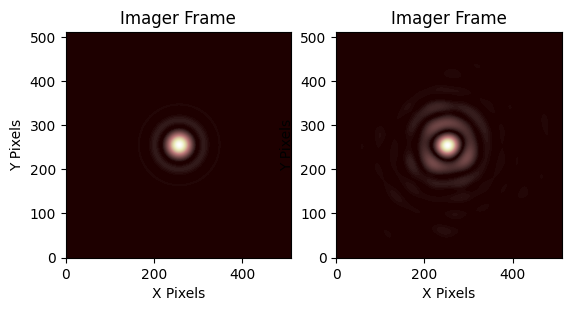

In [66]:
plt.subplot(1,2,1)
plt.imshow(referenceFrame, cmap='pink', origin='lower')
plt.title('Imager Frame')
plt.xlabel('X Pixels')
plt.ylabel('Y Pixels')

plt.subplot(1,2,2)
plt.imshow(frame, cmap='pink', origin='lower')
plt.title('Imager Frame')
plt.xlabel('X Pixels')
plt.ylabel('Y Pixels')
plt.show()

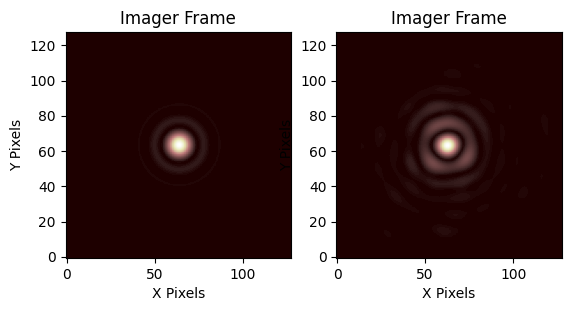

In [70]:
from skimage.transform import resize
referenceFrame = resize(referenceFrame, (128,128), mode='reflect', anti_aliasing=True)
frame = resize(frame, (128,128), mode='reflect', anti_aliasing=True)
plt.subplot(1,2,1)
plt.imshow(referenceFrame, cmap='pink', origin='lower')
plt.title('Imager Frame')
plt.xlabel('X Pixels')
plt.ylabel('Y Pixels')

plt.subplot(1,2,2)
plt.imshow(frame, cmap='pink', origin='lower')
plt.title('Imager Frame')
plt.xlabel('X Pixels')
plt.ylabel('Y Pixels')
plt.show()

In [72]:
wfs.signal.shape[0]

616

In [74]:
dm.coefs.shape[0]

357